**import libraries**

In [228]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from packaging import version
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

**Load dataset**

In [229]:
df = pd.read_csv("/content/loan_approval_dataset.csv")
print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

✅ Dataset loaded successfully.
Shape: (4269, 13)

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**Clean and prepare the data**

In [230]:
df = df.copy()
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

**Convert target to binary**

In [231]:
if 'loan_status' in df.columns:
    df['loan_status'] = df['loan_status'].replace({'Approved':1, 'Rejected':0})
else:
    raise ValueError("❌ Column 'loan_status' not found!")

/tmp/ipython-input-4020630961.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].replace({'Approved':1, 'Rejected':0})


**Drop missing targets**

In [232]:
df = df.dropna(subset=['loan_status'])

**Split features and target**

In [233]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("\nCategorical features:", cat_cols)
print("Numerical features:", num_cols)


Categorical features: ['education', 'self_employed']
Numerical features: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


**Preprocessing pipelines**

In [234]:
if version.parse(sklearn.__version__) >= version.parse("1.2"):
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
else:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

**Train/Test Split**

In [235]:
RND = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RND, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 3415, Test size: 854


**Apply preprocessing**

In [236]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

print("\nData preprocessing completed successfully.")
print("Encoded training shape:", X_train_enc.shape)


Data preprocessing completed successfully.
Encoded training shape: (3415, 14)


**Balance data with SMOTE**

In [237]:
sm = SMOTE(random_state=RND)
X_train_bal, y_train_bal = sm.fit_resample(X_train_enc, y_train)
print("\n✅ After SMOTE class distribution:")
print(pd.Series(y_train_bal).value_counts())


✅ After SMOTE class distribution:
loan_status
1    2125
0    2125
Name: count, dtype: int64


**Train models**

In [238]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RND),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RND)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_enc)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred, digits=3))
    results[name] = classification_report(y_test, y_pred, output_dict=True)


Model: Logistic Regression
              precision    recall  f1-score   support

           0      0.880     0.932     0.905       323
           1      0.957     0.923     0.940       531

    accuracy                          0.926       854
   macro avg      0.919     0.927     0.922       854
weighted avg      0.928     0.926     0.927       854


Model: Decision Tree
              precision    recall  f1-score   support

           0      0.949     0.972     0.960       323
           1      0.983     0.968     0.975       531

    accuracy                          0.970       854
   macro avg      0.966     0.970     0.968       854
weighted avg      0.970     0.970     0.970       854



**Summary Table of Metrics**

In [239]:
comparison = pd.DataFrame({
    model: {
        "Precision": round(results[model]["weighted avg"]["precision"], 3),
        "Recall": round(results[model]["weighted avg"]["recall"], 3),
        "F1-score": round(results[model]["weighted avg"]["f1-score"], 3)
    }
    for model in results
}).T

print("\nModel Comparison Table:")
display(comparison)


Model Comparison Table:


,Precision,Recall,F1-score
Logistic Regression,0.928,0.926,0.927
Decision Tree,0.970,0.970,0.970


**Confusion Matrices & Feature Importance**

In [240]:
def plot_combined_dashboard(models, X_test, y_test, preprocessor, model_names):
    num_models = len(models)
    fig, axes = plt.subplots(2, num_models, figsize=(16, 10))

    for i, (name, model) in enumerate(models.items()):
        # Confusion Matrix
        cm = confusion_matrix(y_test, model.predict(X_test))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i],
                    xticklabels=[0,1], yticklabels=[0,1])
        axes[0, i].set_title(f'Confusion Matrix\n{name}')
        axes[0, i].set_xlabel('Predicted')
        axes[0, i].set_ylabel('Actual')

        # Feature Importance / Coefficients
        cat_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
        all_features = num_cols + list(cat_features)

        if isinstance(model, DecisionTreeClassifier):
            feat_values = model.feature_importances_
            palette = "viridis"
            xlabel = "Importance"
        elif isinstance(model, LogisticRegression):
            coef = model.coef_[0]
            feat_values = coef
            palette = ['green' if c > 0 else 'red' for c in coef]
            xlabel = "Coefficient Value"

        sns.barplot(x=feat_values, y=all_features, palette=palette, ax=axes[1, i])
        axes[1, i].set_title(f'Feature Importance / Coefficients\n{name}')
        axes[1, i].set_xlabel(xlabel)
        axes[1, i].set_ylabel('Features')

    plt.tight_layout()
    plt.show()

**Dahboards**

/tmp/ipython-input-4275974871.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_values, y=all_features, palette=palette, ax=axes[1, i])
/tmp/ipython-input-4275974871.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_values, y=all_features, palette=palette, ax=axes[1, i])


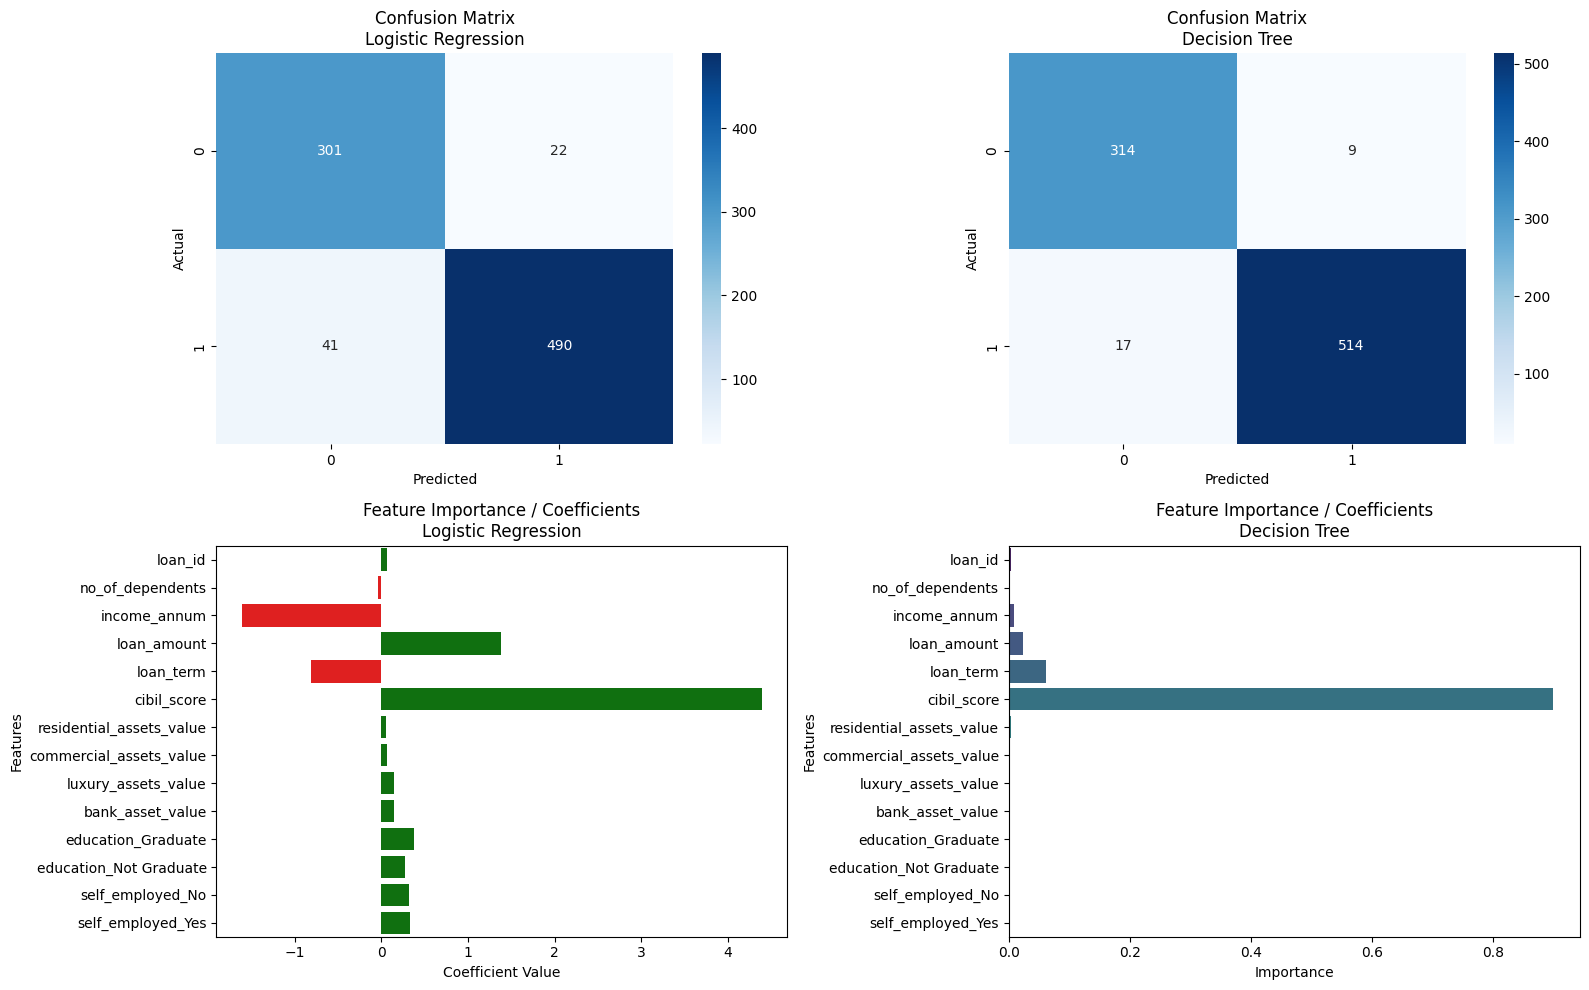

In [241]:
plot_combined_dashboard(models, X_test_enc, y_test, preprocessor, list(models.keys()))